# SEQUENTIAL

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Define the directory you want to search in
directory = Path(
    "C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\coe_results"
)
files = [
    file for file in directory.rglob("*") if file.is_file() and "BTC_USD" in file.parts
]

In [14]:
best_strategy = {
    "BTC_USD": {
        "univariate_hawkes": "training_time_600",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_900",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "real_time",
    },
}
"""    "BTC_USDT": {
        "univariate_hawkes": "training_time_300",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
    "ETH_BTC": {
        "univariate_hawkes": "training_time_300",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
    "ETH_USD": {
        "univariate_hawkes": "training_time_600",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
    "ETH_USDT": {
        "univariate_hawkes": "training_time_900",
        "multivariate_hawkes": "lshade_training_time_900",
        "moving_average": "window_duration_seconds_30",
        "poisson": "training_time_300",
        "naive": "next_time_jump_seconds_ 1",
        "oracle": "correct_time",
    },
}"""

'    "BTC_USDT": {\n        "univariate_hawkes": "training_time_300",\n        "multivariate_hawkes": "lshade_training_time_900",\n        "moving_average": "window_duration_seconds_30",\n        "poisson": "training_time_300",\n        "naive": "next_time_jump_seconds_ 1",\n        "oracle": "correct_time",\n    },\n    "ETH_BTC": {\n        "univariate_hawkes": "training_time_300",\n        "multivariate_hawkes": "lshade_training_time_900",\n        "moving_average": "window_duration_seconds_30",\n        "poisson": "training_time_300",\n        "naive": "next_time_jump_seconds_ 1",\n        "oracle": "correct_time",\n    },\n    "ETH_USD": {\n        "univariate_hawkes": "training_time_600",\n        "multivariate_hawkes": "lshade_training_time_900",\n        "moving_average": "window_duration_seconds_30",\n        "poisson": "training_time_300",\n        "naive": "next_time_jump_seconds_ 1",\n        "oracle": "correct_time",\n    },\n    "ETH_USDT": {\n        "univariate_hawkes":

In [15]:
def same_sign(a, b):
    return (a >= 0 and b >= 0) or (a < 0 and b < 0)


dfs = []
for file in files:
    fileparts = file.parts
    method = fileparts[-5]
    pair = fileparts[-4]
    param = fileparts[-3]
    bi_level = fileparts[-2]
    filename = fileparts[-1]

    if best_strategy[pair][method] != param:
        continue

    prediction_df = pd.read_csv(file, sep="\t")
    if method == "oracle":
        real_df = pd.read_csv(
            f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\filtered_sampled\\naive\\{pair}\\next_time_jump_seconds_ 1\\120\\{bi_level}\\{filename}",
            sep="\t",
        )
    else:
        real_df = pd.read_csv(
            f"C:\\Users\\Admin\\OneDrive - Politecnico di Milano\\phd\\code\\multivariate_hawkes\\data\\coe_dataframes\\simulation_dataframes\\filtered_sampled\\{method}\\{pair}\\{param}\\120\\{bi_level}\\{filename}",
            sep="\t",
        )
    comparison_df = pd.concat([prediction_df, real_df], axis=1)
    comparison_df = comparison_df.dropna()

    comparison_df["sign_predicted"] = comparison_df[
        ["predicted_return", "Return"]
    ].apply(lambda x: same_sign(x["predicted_return"], x["Return"]), axis=1)
    df = comparison_df[["sign_predicted", "Return"]].copy()
    df["method"] = method
    df["pair"] = pair
    df["param"] = param
    df["bi_level"] = bi_level
    df["filename"] = filename

    dfs.append(df)

df = pd.concat(dfs)
df.head()

,sign_predicted,Return,method,pair,param,bi_level,filename
0,True,0.000082,moving_average,BTC_USD,window_duration_seconds_30,bi_level_10,orderbook_changes_1705356920082_1705353321.tsv
1,False,0.000047,moving_average,BTC_USD,window_duration_seconds_30,bi_level_10,orderbook_changes_1705356920082_1705353321.tsv
2,True,-0.000047,moving_average,BTC_USD,window_duration_seconds_30,bi_level_10,orderbook_changes_1705356920082_1705353321.tsv
3,False,-0.000047,moving_average,BTC_USD,window_duration_seconds_30,bi_level_10,orderbook_changes_1705356920082_1705353321.tsv
4,False,0.000012,moving_average,BTC_USD,window_duration_seconds_30,bi_level_10,orderbook_changes_1705356920082_1705353321.tsv


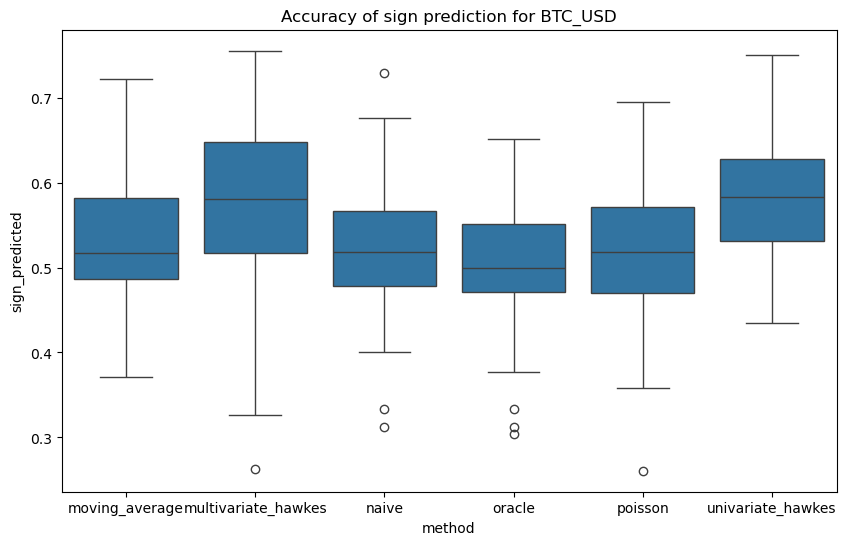

In [16]:
for pair in df["pair"].unique():
    df_pair = df[df["pair"] == pair]
    df_accuracy = (
        df_pair[["method", "sign_predicted", "filename"]]
        .groupby(["method", "filename"])
        .mean()
    )
    df_accuracy = df_accuracy.reset_index()

    plt.figure(figsize=(10, 6))
    sns.boxplot(x="method", y="sign_predicted", data=df_accuracy)
    plt.title(f"Accuracy of sign prediction for {pair}")